IMPORT SECTION

In [1]:
import os
from utils.utils import process_data
import tensorflow_datasets as tfds
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

DOWNLOAD DROID DATA

In [ ]:
 # List of the dataset of OXE to download
dataset_list = ["droid"]
download_dir = f"./data/{dataset_list[0]}" # directory where to download the pytorch tensors needed for offline training
os.makedirs(download_dir, exist_ok=True)

# Load in streaming the dataset
ds = tfds.load(dataset_list[0], data_dir="gs://gresearch/robotics", split="train")

droid_lang_keys = ['language_instruction', 'language_instruction_2', 'language_instruction_3']
num_episodes_to_download = 100
for i, episode in enumerate(tqdm(ds, total=num_episodes_to_download, desc=f"Download {dataset_list[0]} episodes", unit="ep")):
    
    # Per ora metti un limite per testare (es. i primi 50 episodi)
    if i >= num_episodes_to_download: 
        break
    
    print(f"--- Episode {i} received from Cloud")
    video_pt, states_pt, action_pt, language_instructions = process_data(episode=episode, 
                                                                         num_frames=16, 
                                                                         fps=15, 
                                                                         window_second_size=4, 
                                                                         lang_keys=droid_lang_keys)
    if video_pt is not None:
        sample = {
            "video": video_pt,      # [16, 3, 256, 256]
            "states": states_pt,    # [16, 7]
            "actions": action_pt,   # [15, 7]
            "language": language_instructions
        }
        
        file_path = os.path.join(download_dir, f"episode_{i}.pt")
        torch.save(sample, file_path)
        print(f"Saved: {file_path}")
    else:
        tqdm.write(f"Episode {i} passed (less then minimum length)")
        pass



Visualizzando l'episodio con istruzione: Pick up the blue ring from the table and put it in the wooden tray


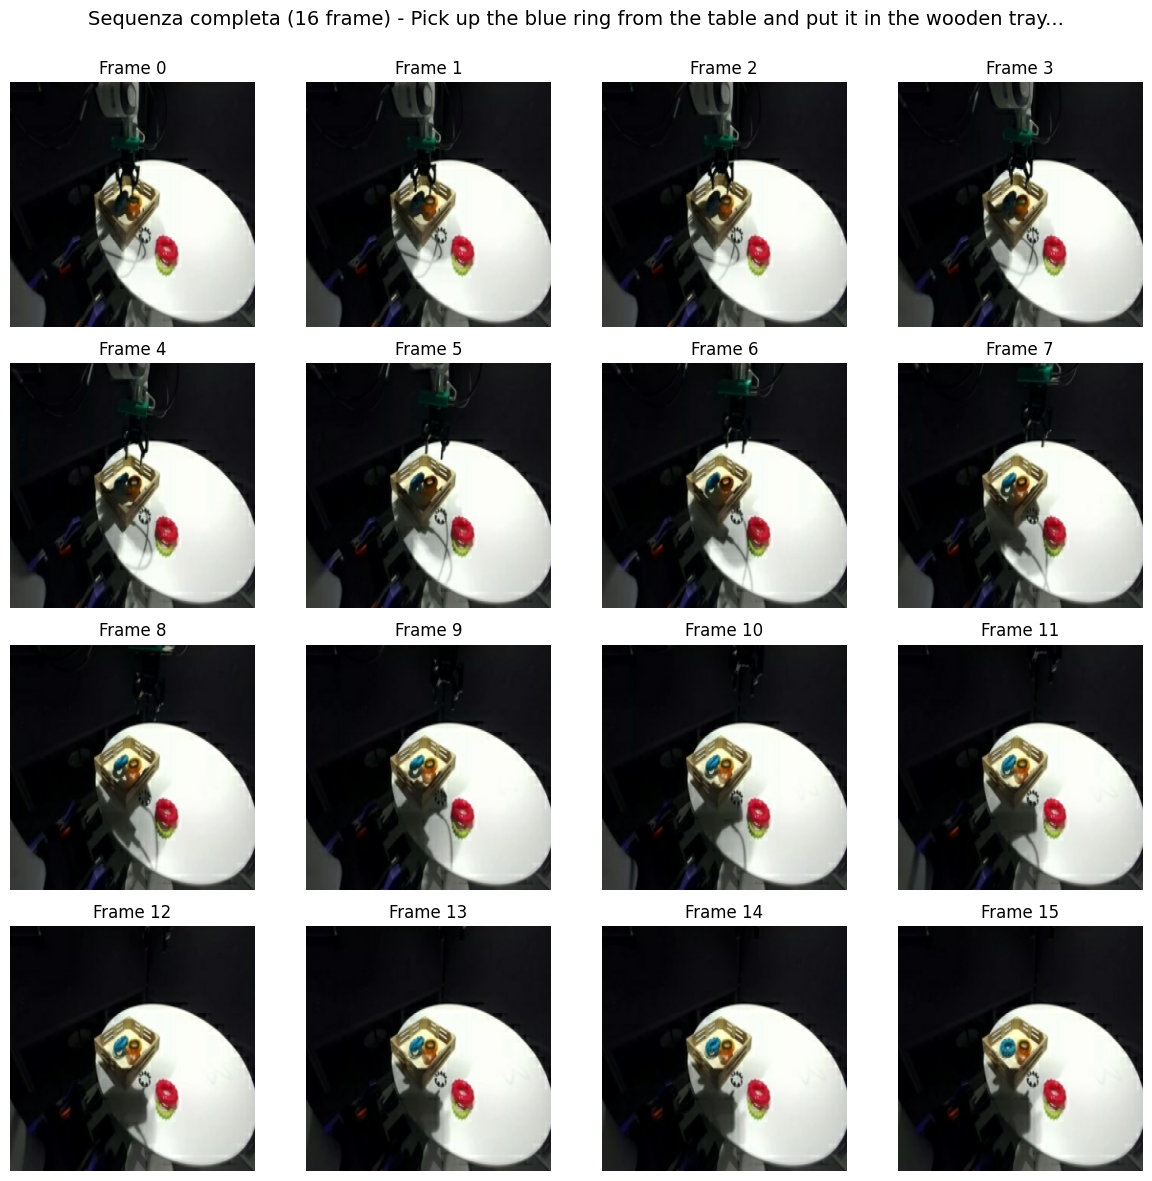


Energia del movimento (norma dell'azione) tra i frame:
[0.23789027 0.04691691 0.06683986 0.06747144 0.06251147 0.06970658
 0.05493833 0.06855948 0.08457971 0.10241424 0.07252613 0.05101622
 0.04007423 0.02288216 0.02017049]


In [3]:
# 1. Carica il file
file_path = "./data/droid/episode_0.pt"
checkpoint = torch.load(file_path)

# 2. Estrazione video e info
video = checkpoint['video']  # [16, 3, 256, 256]
instruction = checkpoint['language'][0]

print(f"Visualizzando l'episodio con istruzione: {instruction}")

# 3. Creazione della griglia 4x4
plt.style.use('default')
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle(f"Sequenza completa (16 frame) - {instruction[:80]}...", fontsize=14)

for i in range(16):
    ax = axes[i // 4, i % 4]
    
    # Prendi il frame i, sposta i canali da [C, H, W] a [H, W, C]
    frame = video[i].permute(1, 2, 0).numpy()
    
    ax.imshow(frame)
    ax.set_title(f"Frame {i}")
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Spazio per il titolo principale
plt.show()

# 4. Verifica dinamica delle azioni
# Calcoliamo la "magnitudo" del movimento per vedere se i frame sono diversi
movement = torch.norm(checkpoint['actions'], dim=1)
print("\nEnergia del movimento (norma dell'azione) tra i frame:")
print(movement.numpy())